# ProximityGraphs Gallery and Metrics

This notebook mirrors the richer examples in this folder, but keeps the story inline: build a small deterministic graph gallery, inspect the metrics, then use the high-level `Experiment` API to compare several graph families across seeded simulations.

All output is written under `examples/output/notebook/` so the notebook can be rerun without needing external data files.

## Setup

The path setup below lets the notebook run from either the repository root or from inside the `examples/` folder. Matplotlib uses the non-interactive backend so the same cells also work in CI or a headless terminal.

In [1]:
from pathlib import Path
import sys

import matplotlib

matplotlib.use("Agg")

import pandas as pd
from IPython.display import Image, display


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "examples").exists():
            return path
    raise RuntimeError("Run this notebook from the repository or examples folder.")


REPO_ROOT = find_repo_root()
EXAMPLES_DIR = REPO_ROOT / "examples"
NOTEBOOK_OUTPUT = EXAMPLES_DIR / "output" / "notebook"
NOTEBOOK_OUTPUT.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(EXAMPLES_DIR))

import proximitygraphs as pg
import experiment_metrics
import quickstart

## A Small Deterministic Graph Gallery

The quickstart example uses a 3x3 grid because the structure is easy to inspect visually. We compare five classical proximity graphs on the same point set: MST, unit disk, Gabriel, relative neighborhood, and Delaunay.

points: 9
saved gallery: examples\output\notebook\quickstart\graph_gallery.png
saved metrics: examples\output\notebook\quickstart\metrics.csv


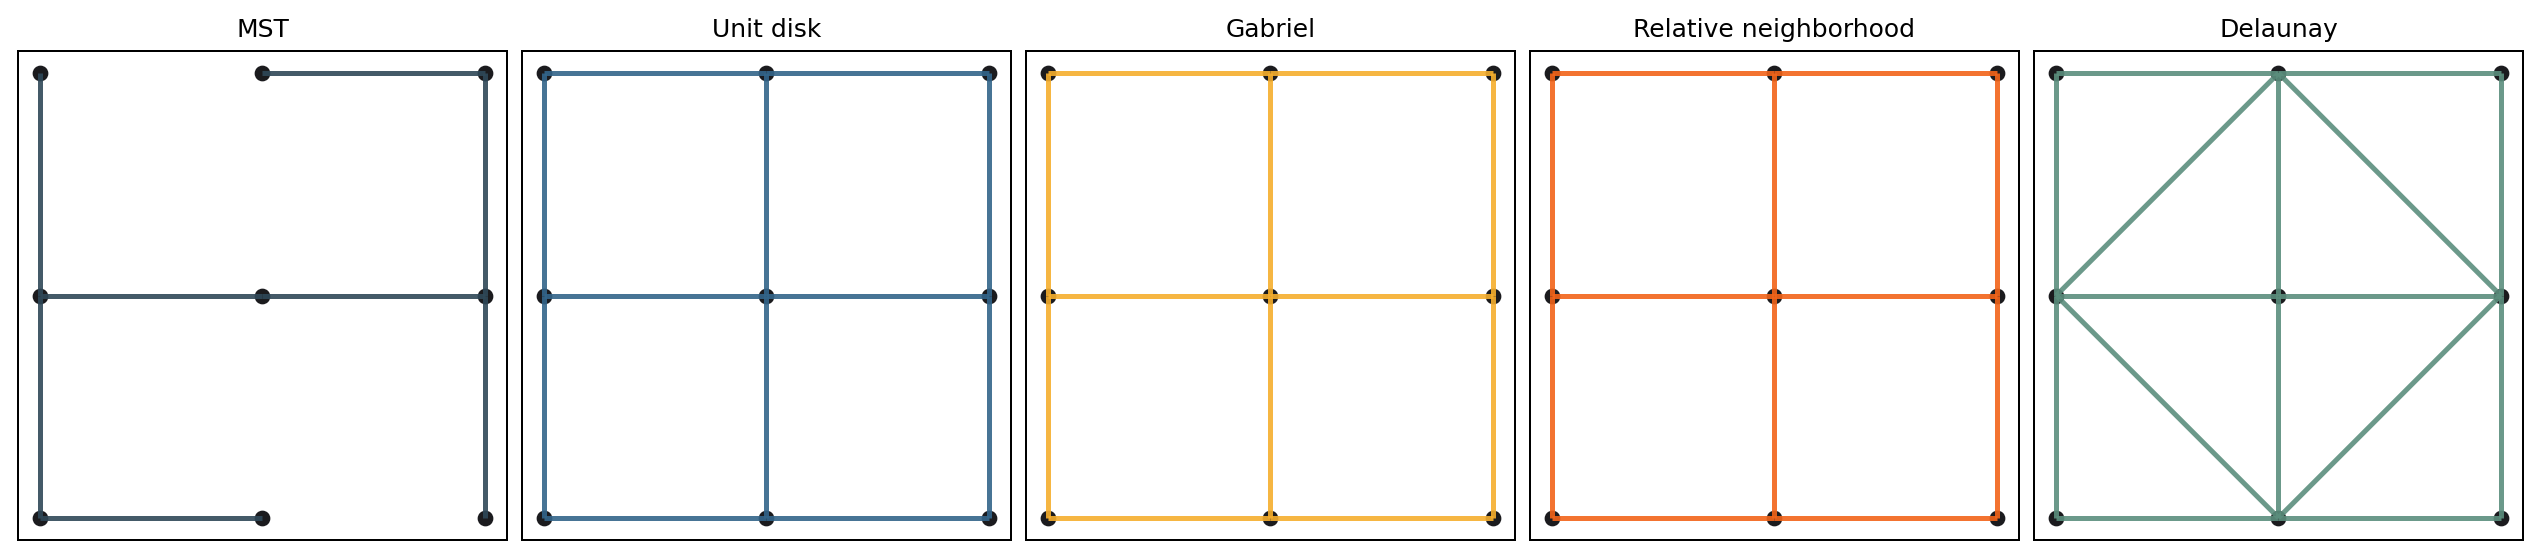

,graph,vertices,edges,components,density,total_length
0,MST,9,8,1,0.2222,8.0000
1,Unit disk,9,12,1,0.3333,12.0000
2,Gabriel,9,12,1,0.3333,12.0000
3,Relative neighborhood,9,12,1,0.3333,12.0000
4,Delaunay,9,16,1,0.4444,17.6569


In [2]:
points, graphs = quickstart.build_graphs()
metrics = quickstart.graph_metrics(graphs)

gallery_dir = NOTEBOOK_OUTPUT / "quickstart"
gallery_path = quickstart.save_graph_gallery(graphs, gallery_dir)
metrics_csv, metrics_md = quickstart.write_metrics(metrics, gallery_dir)

print(f"points: {points.n}")
print(f"saved gallery: {gallery_path.relative_to(REPO_ROOT)}")
print(f"saved metrics: {metrics_csv.relative_to(REPO_ROOT)}")
display(Image(filename=str(gallery_path)))
metrics

The edge counts and total lengths show the expected progression: the MST is sparse and length-minimizing, the unit disk/Gabriel/RNG examples coincide on this grid radius, and Delaunay adds the diagonal triangulation edges.

## Experiment-Level Comparison

The `Experiment` interface is the higher-level workflow users will typically rely on. Here we run four seeded simulations over a shared random point generation setup and compare six graph families, including a bio-inspired fungal graph.

In [3]:
experiment = experiment_metrics.build_experiment()
results = experiment.run(store_graphs=True)

experiment_dir = NOTEBOOK_OUTPUT / "experiment_metrics"
results_path, aggregate_path, summary_path = experiment_metrics.write_summary(
    experiment, experiment_dir
)
plot_paths = experiment_metrics.save_metric_plots(experiment, experiment_dir)

print(f"rows: {len(results)}")
print(f"saved results: {results_path.relative_to(REPO_ROOT)}")
print(f"saved aggregate: {aggregate_path.relative_to(REPO_ROOT)}")
print(f"saved summary: {summary_path.relative_to(REPO_ROOT)}")
results.head()

rows: 24
saved results: examples\output\notebook\experiment_metrics\results.csv
saved aggregate: examples\output\notebook\experiment_metrics\aggregate.csv
saved summary: examples\output\notebook\experiment_metrics\summary.txt


,simulation,graph_type,n_vertices,n_edges,n_components,n_faces,mean_degree,std_degree,min_degree,max_degree,mean_length,std_length,min_length,max_length,total_length,entropy_degree,entropy_length,entropy_orientation,is_connected,density
0,0,MST,18,17,1,1,1.888889,0.808901,1,3,0.166988,0.056220,0.052351,0.267229,2.838798,1.571542,3.130718,3.852169,True,0.111111
1,0,RNG,18,17,1,1,1.888889,0.808901,1,3,0.166988,0.056220,0.052351,0.267229,2.838798,1.571542,3.130718,3.852169,True,0.111111
2,0,Gabriel,18,32,1,16,3.555556,1.300522,1,6,0.220802,0.092382,0.052351,0.441758,7.065663,2.258460,3.014819,4.265320,True,0.209150
3,0,Unit disk,18,38,1,22,4.222222,1.842569,1,7,0.203381,0.064724,0.052351,0.313364,7.728483,2.752715,3.201912,4.398857,True,0.248366
4,0,Gamma,18,2,16,1,0.222222,0.415740,0,1,0.074445,0.022094,0.052351,0.096539,0.148891,0.764205,1.000000,1.000000,False,0.013072


The aggregate table summarizes each graph family across simulations. `n_edges` and `density` are structural; `total_length` captures the geometric cost of the network.

In [4]:
aggregate = pd.read_csv(aggregate_path, header=[0, 1], index_col=0)
aggregate.round(4)

n_edges                 total_length                            \
              mean     std min max         mean     std      min      max   
graph_type                                                                  
Fungal       51.00  1.8257  49  53      14.4447  1.8113  12.8512  17.0211   
Gabriel      27.00  3.7417  23  32       5.6528  0.9540   4.9682   7.0657   
Gamma         4.50  1.7321   2   6       0.4972  0.2602   0.1489   0.7611   
MST          17.00  0.0000  17  17       2.7738  0.1330   2.5834   2.8851   
RNG          18.25  1.2583  17  20       3.1034  0.3939   2.7201   3.5663   
Unit disk    42.25  7.8899  35  53       8.7176  1.7327   7.0191  10.9366   

           density                          
              mean     std     min     max  
graph_type                                  
Fungal      0.3333  0.0119  0.3203  0.3464  
Gabriel     0.1765  0.0245  0.1503  0.2092  
Gamma       0.0294  0.0113  0.0131  0.0392  
MST         0.1111  0.0000  0.1111  0.1111  
RNG         0.1193  0.0082  0.1111  0.1307  
Unit disk   0.2761  0.0516  0.2288  0.3464

## Saved Metric Plots

The plots below are produced by the experiment helper. They make it easier to spot structural differences quickly: sparse tree-like models, denser radius-threshold models, and the growth heuristic used by the fungal graph.

examples\output\notebook\experiment_metrics\n_edges.png


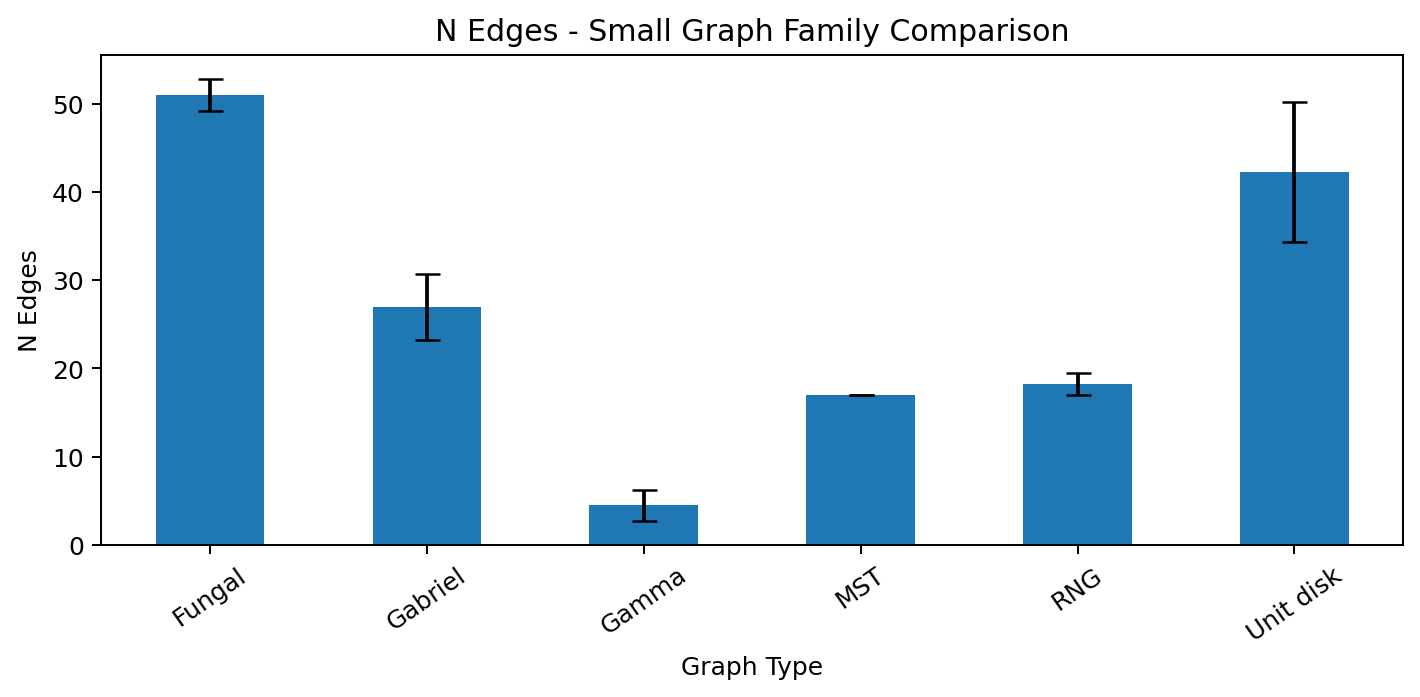

examples\output\notebook\experiment_metrics\total_length.png


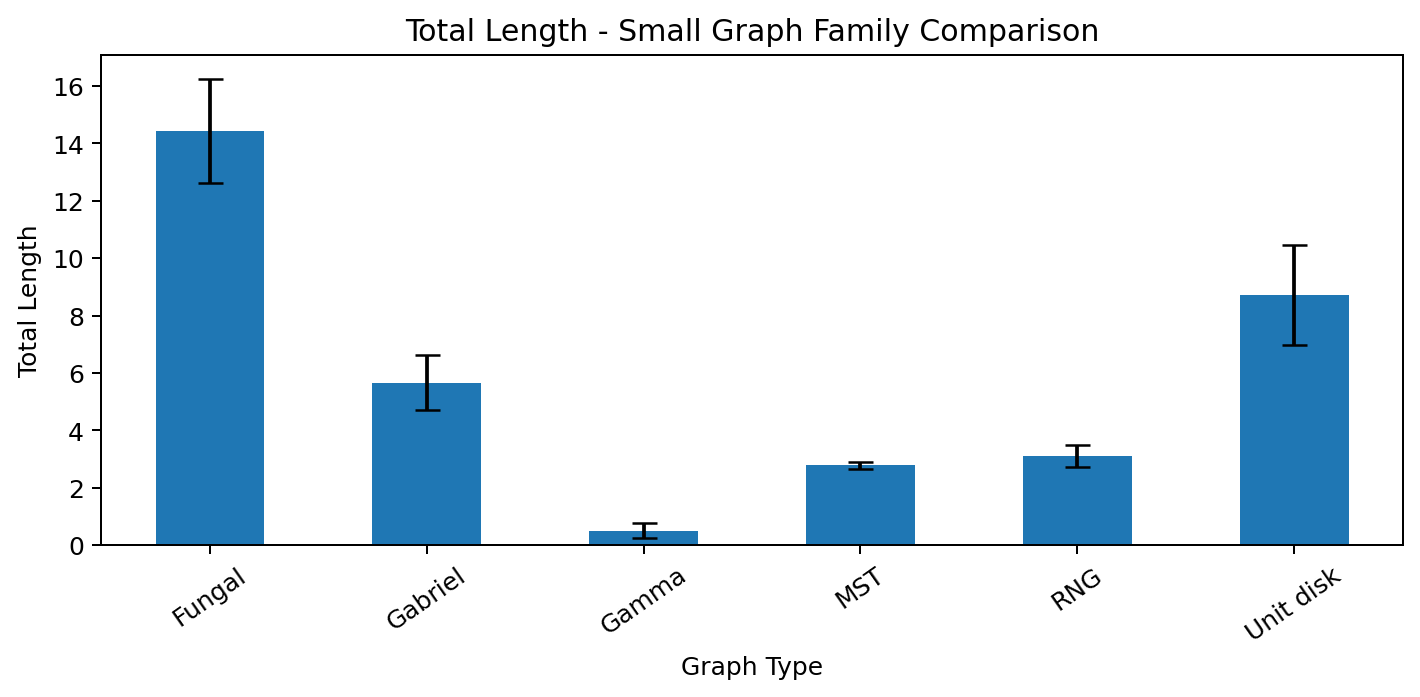

examples\output\notebook\experiment_metrics\density.png


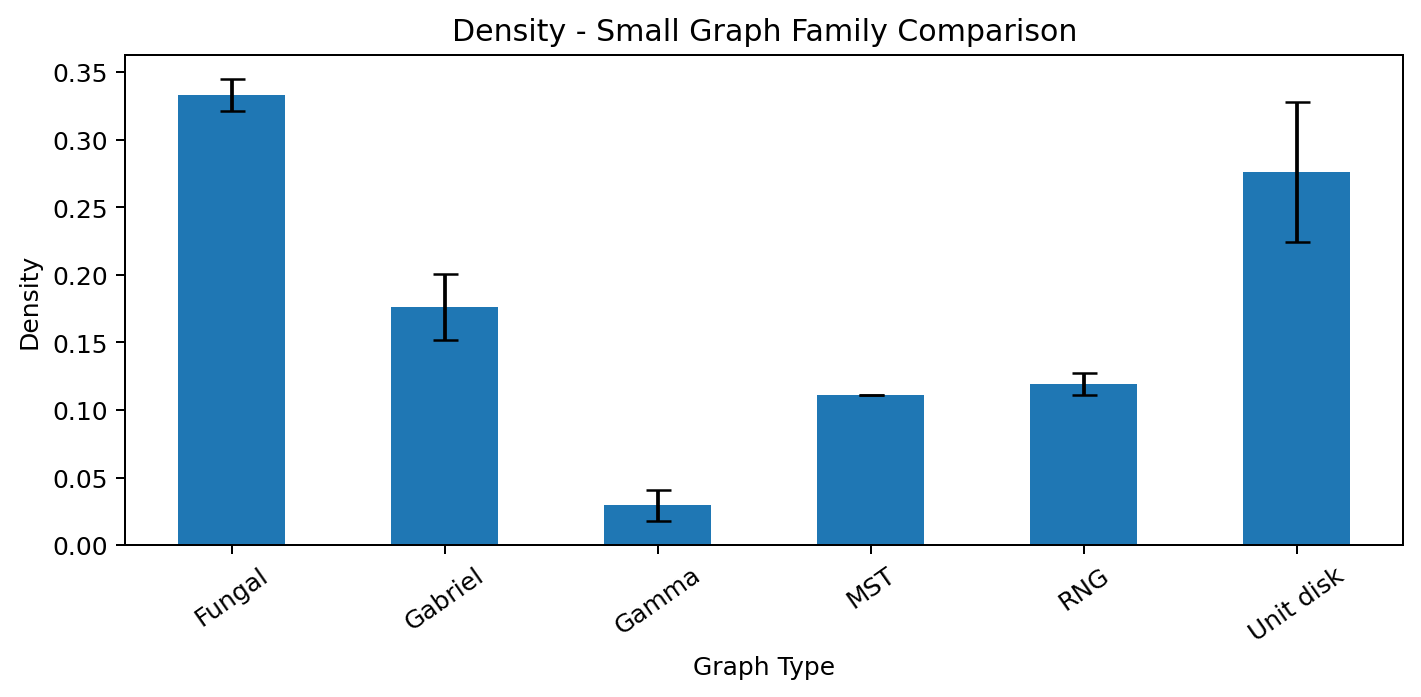

In [5]:
for path in plot_paths:
    print(path.relative_to(REPO_ROOT))
    display(Image(filename=str(path)))

## Where the Artifacts Land

The notebook saves reusable artifacts next to the scripted examples:

- graph gallery PNG
- quickstart metrics CSV and Markdown table
- experiment results CSV
- experiment aggregate CSV
- experiment summary text
- metric comparison PNGs

That makes the notebook useful both as a tutorial and as a reproducible artifact generator.